# Diffusion Model for RT Price Super-Resolution — Walkthrough

This notebook demonstrates the full pipeline on a tiny slice of data so you can see every step quickly:

1. **Raw data** — what DA and RT prices look like
2. **Normalization** — arcsinh + z-score, and why it matters for price spikes
3. **Forward diffusion** — watching a clean price trace get destroyed by noise
4. **Training** — a small model trained for a few epochs on ~100 days
5. **Sampling** — DDPM vs DDIM, generating RT traces from DA conditioning
6. **Evaluation** — distribution, volatility, autocorrelation
7. **Battery arbitrage** — LP optimization on real vs generated prices to measure economic value fidelity

In [14]:
import sys, os
sys.path.insert(0, os.path.abspath('.'))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import torch
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
from tqdm.notebook import tqdm

from data.preprocess import arcsinh_transform, arcsinh_inverse, load_da, load_rt, build_daily_arrays
from models import UNet1D, NoiseSchedule, DDPMTrainer
from models.diffusion import sample_ddpm, sample_ddim

plt.rcParams.update({'figure.dpi': 110, 'font.size': 11})

device = (
    torch.device('cuda') if torch.cuda.is_available()
    else torch.device('mps') if torch.backends.mps.is_available()
    else torch.device('cpu')
)
print(f'Device: {device}')

Device: mps


## 1. Raw Data

We have two datasets for node `48806`:
- **DA** (day-ahead): 24 hourly prices per day, cleared the morning before delivery
- **RT** (real-time): 288 five-minute prices per day, actual market outcomes

Let's load a few months and look at what a typical day looks like.

In [15]:
PNODE = 48806

# Load a few months just for exploration
da_raw = load_da('./pjm_lmps_da', PNODE)
rt_raw = load_rt('./pjm_lmps', PNODE)

dates, da_arr, rt_arr = build_daily_arrays(da_raw, rt_raw)
print(f'{len(dates)} complete days available ({dates[0]} → {dates[-1]})')
print(f'DA shape: {da_arr.shape}   RT shape: {rt_arr.shape}')

1803 complete days available (2020-10-14 → 2025-10-13)
DA shape: (1803, 24)   RT shape: (1803, 288)


Example day: 2022-08-09  (RT std=397.1 $/MWh)


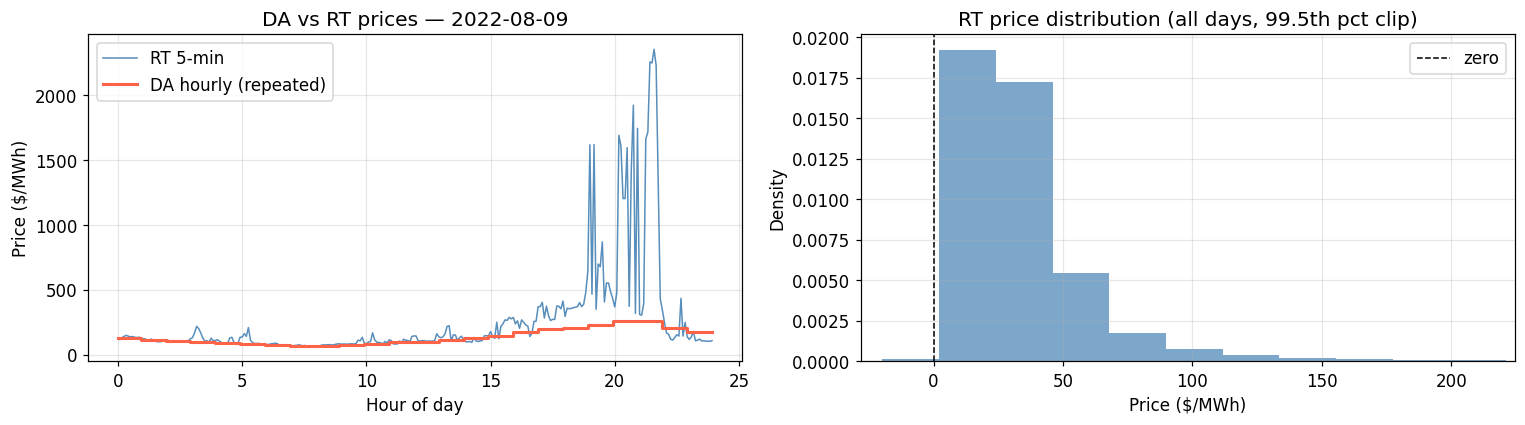

RT stats — mean: 36.7  std: 66.2  min: -392.3  max: 3990.1  neg: 0.3%


In [16]:
# Pick an interesting day to visualize — find a high-volatility day
volatilities = rt_arr.std(axis=1)
example_idx = int(np.argsort(volatilities)[-5])  # 5th most volatile day
print(f'Example day: {dates[example_idx]}  (RT std={volatilities[example_idx]:.1f} $/MWh)')

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Left: DA (hourly) vs RT (5-min) overlay
ax = axes[0]
rt_hours = np.arange(288) / 12           # convert 5-min intervals to hours
da_hours = np.arange(24) + 0.5          # hour centers
da_step  = np.repeat(da_arr[example_idx], 12)  # repeat hourly DA to 288 points

ax.plot(rt_hours, rt_arr[example_idx], color='steelblue', lw=1, label='RT 5-min', alpha=0.9)
ax.step(rt_hours, da_step, color='tomato', lw=2, label='DA hourly (repeated)', where='pre')
ax.set_xlabel('Hour of day'); ax.set_ylabel('Price ($/MWh)')
ax.set_title(f'DA vs RT prices — {dates[example_idx]}')
ax.legend(); ax.grid(alpha=0.3)

# Right: distribution of all RT prices
ax = axes[1]
ax.hist(rt_arr.ravel(), bins=200, color='steelblue', alpha=0.7, density=True)
ax.axvline(0, color='black', lw=1, ls='--', label='zero')
ax.set_xlim(np.percentile(rt_arr, 0.1), np.percentile(rt_arr, 99.5))
ax.set_xlabel('Price ($/MWh)'); ax.set_ylabel('Density')
ax.set_title('RT price distribution (all days, 99.5th pct clip)')
ax.legend(); ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

print(f'RT stats — mean: {rt_arr.mean():.1f}  std: {rt_arr.std():.1f}  '
      f'min: {rt_arr.min():.1f}  max: {rt_arr.max():.1f}  '
      f'neg: {(rt_arr<0).mean():.1%}')

## 2. Normalization — arcsinh + z-score

Electricity prices are heavy-tailed with occasional extreme spikes and negative values.
Standard z-score alone fails because a single $5000 spike dominates the variance.

We use `arcsinh(x/100)` first:
- Behaves like `log(x)` for large positives (compresses spikes)
- Handles negatives cleanly (unlike log)
- Linear near zero — doesn't distort the normal price range

The `/ 100` sets the "compression knee" at roughly ±$100/MWh.

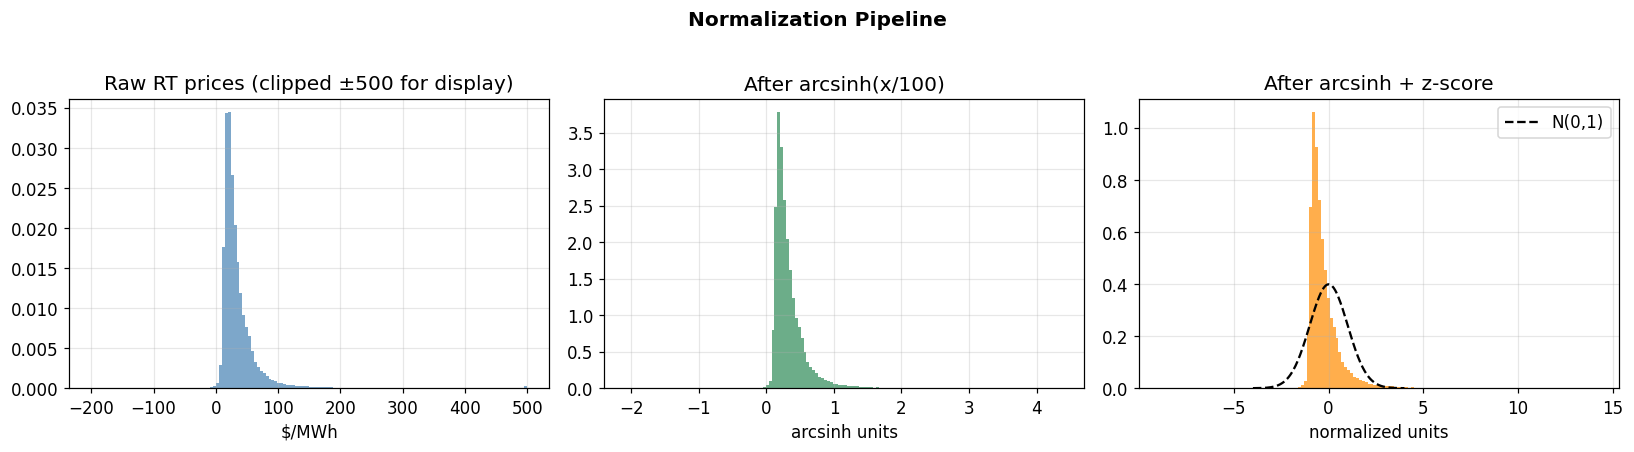

Scaler — mean: 0.4045, std: 0.2804
Normalized — mean: -0.2587, std: 0.8970


In [17]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

prices = rt_arr.ravel()
clip_pct = np.percentile(np.abs(prices), 99)

# Raw
ax = axes[0]
ax.hist(np.clip(prices, -200, 500), bins=150, color='steelblue', alpha=0.7, density=True)
ax.set_title('Raw RT prices (clipped ±500 for display)')
ax.set_xlabel('$/MWh'); ax.grid(alpha=0.3)

# After arcsinh
transformed = arcsinh_transform(prices)
ax = axes[1]
ax.hist(transformed, bins=150, color='seagreen', alpha=0.7, density=True)
ax.set_title('After arcsinh(x/100)')
ax.set_xlabel('arcsinh units'); ax.grid(alpha=0.3)

# After arcsinh + z-score
# Fit on a representative training subset
train_days = da_arr[:800]  # rough training slice for demo
train_rt   = rt_arr[:800]
all_train_transformed = arcsinh_transform(np.concatenate([train_days, train_rt], axis=1).ravel())
sc_mean = all_train_transformed.mean()
sc_std  = all_train_transformed.std()
normalized = (transformed - sc_mean) / sc_std

ax = axes[2]
ax.hist(normalized, bins=150, color='darkorange', alpha=0.7, density=True)
x = np.linspace(-4, 4, 200)
ax.plot(x, np.exp(-x**2/2)/np.sqrt(2*np.pi), 'k--', lw=1.5, label='N(0,1)')
ax.set_title('After arcsinh + z-score')
ax.set_xlabel('normalized units'); ax.legend(); ax.grid(alpha=0.3)

plt.suptitle('Normalization Pipeline', y=1.02, fontweight='bold')
plt.tight_layout()
plt.show()

print(f'Scaler — mean: {sc_mean:.4f}, std: {sc_std:.4f}')
print(f'Normalized — mean: {normalized.mean():.4f}, std: {normalized.std():.4f}')

## 3. Mini Dataset

For this walkthrough we use just 150 days for training and 30 for validation.
We also use a tiny model (`base_channels=16`) and only `T=200` diffusion timesteps
so training completes quickly.

In [18]:
# Use a small subset
N_TRAIN = 150
N_VAL   = 30

def normalize(x, mean, std):
    return (arcsinh_transform(x) - mean) / std

def denormalize(x, mean, std):
    return arcsinh_inverse(x * std + mean)

da_norm = normalize(da_arr, sc_mean, sc_std)   # (N, 24)
rt_norm = normalize(rt_arr, sc_mean, sc_std)   # (N, 288)

# Upsample DA 24 → 288 by repeating each hour 12 times
da_norm_288 = np.repeat(da_norm, 12, axis=1)   # (N, 288)

def make_tensor_loader(da, rt, batch_size, shuffle=True):
    da_t = torch.tensor(da, dtype=torch.float32).unsqueeze(1)  # (N, 1, 288)
    rt_t = torch.tensor(rt, dtype=torch.float32).unsqueeze(1)  # (N, 1, 288)
    ds = TensorDataset(da_t, rt_t)
    return DataLoader(ds, batch_size=batch_size, shuffle=shuffle)

train_loader = make_tensor_loader(da_norm_288[:N_TRAIN], rt_norm[:N_TRAIN], batch_size=32)
val_loader   = make_tensor_loader(da_norm_288[N_TRAIN:N_TRAIN+N_VAL], rt_norm[N_TRAIN:N_TRAIN+N_VAL], batch_size=32, shuffle=False)

print(f'Train batches: {len(train_loader)}  Val batches: {len(val_loader)}')
da_sample, rt_sample = next(iter(train_loader))
print(f'Batch shapes — DA: {da_sample.shape}, RT: {rt_sample.shape}')

Train batches: 5  Val batches: 1
Batch shapes — DA: torch.Size([32, 1, 288]), RT: torch.Size([32, 1, 288])


## 4. The Forward Diffusion Process

Before training, let's visualize what the **forward process** does.
Starting from a clean RT price trace, we progressively add Gaussian noise.

The math: `xₜ = √ᾱₜ · x₀ + √(1-ᾱₜ) · ε`

At `t=0`, the trace is clean. At `t=T`, it's pure noise.
The model learns to reverse this — to *denoise* given the DA conditioning.

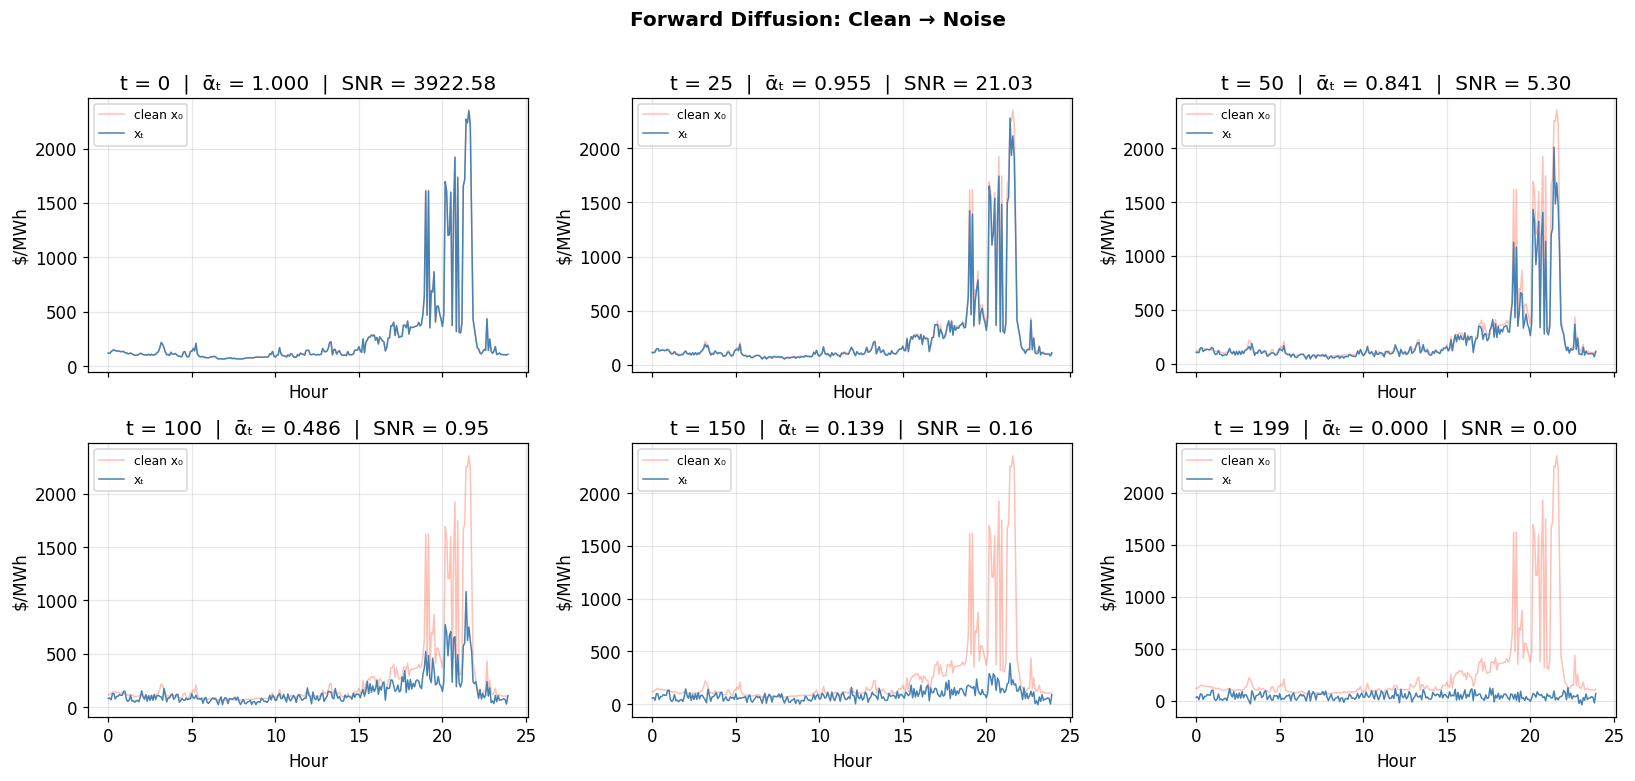

In [19]:
T_MINI = 200
schedule_mini = NoiseSchedule(T=T_MINI, schedule='cosine').to(device)

# Pick one clean RT trace from the dataset
x0 = rt_norm[example_idx]  # (288,) already normalized
x0_t = torch.tensor(x0, dtype=torch.float32).unsqueeze(0).unsqueeze(0).to(device)  # (1,1,288)

timesteps_to_show = [0, 25, 50, 100, 150, 199]
noise = torch.randn_like(x0_t)

fig, axes = plt.subplots(2, 3, figsize=(15, 7), sharex=True)
hours = np.arange(288) / 12

for ax, t_val in zip(axes.ravel(), timesteps_to_show):
    t = torch.tensor([t_val], device=device)
    x_t, _ = schedule_mini.q_sample(x0_t, t, noise=noise)
    noisy = x_t.squeeze().cpu().numpy()
    
    abar = schedule_mini.alphas_bar[t_val].item()
    snr = abar / (1 - abar)  # signal-to-noise ratio
    
    ax.plot(hours, denormalize(x0, sc_mean, sc_std), color='tomato', alpha=0.4, lw=1, label='clean x₀')
    ax.plot(hours, denormalize(noisy, sc_mean, sc_std), color='steelblue', lw=1, label=f'xₜ')
    ax.set_title(f't = {t_val}  |  ᾱₜ = {abar:.3f}  |  SNR = {snr:.2f}')
    ax.set_xlabel('Hour'); ax.set_ylabel('$/MWh')
    ax.legend(fontsize=8); ax.grid(alpha=0.3)

plt.suptitle('Forward Diffusion: Clean → Noise', fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

## 5. Model — Tiny U-Net

We instantiate a small model for this demo (`base_channels=16` instead of the full `64`).
The architecture is identical — just narrower channels.

In [20]:
model = UNet1D(base_channels=16, num_res_blocks=1, attn_heads=4).to(device)
n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Tiny model parameters: {n_params:,}')

# Full model for reference
full_model = UNet1D(base_channels=64, num_res_blocks=2, attn_heads=8)
n_full = sum(p.numel() for p in full_model.parameters() if p.requires_grad)
print(f'Full model parameters: {n_full:,}')

# Quick sanity check
dummy_x = torch.randn(2, 2, 288, device=device)
dummy_t = torch.randint(0, T_MINI, (2,), device=device)
out = model(dummy_x, dummy_t)
print(f'Forward pass: input {dummy_x.shape} → output {out.shape}')

Tiny model parameters: 298,929
Full model parameters: 6,456,897
Forward pass: input torch.Size([2, 2, 288]) → output torch.Size([2, 1, 288])


## 6. Training

Each training step:
1. Sample a random timestep `t` for each item in the batch
2. Add the corresponding amount of noise to the clean RT trace → `xₜ`
3. Feed `[xₜ, DA_conditioning]` into the U-Net
4. Compute MSE between predicted noise and actual noise
5. Backprop

The DA prices never get noise added — they're always clean conditioning.

Training:   0%|          | 0/60 [00:00<?, ?it/s]

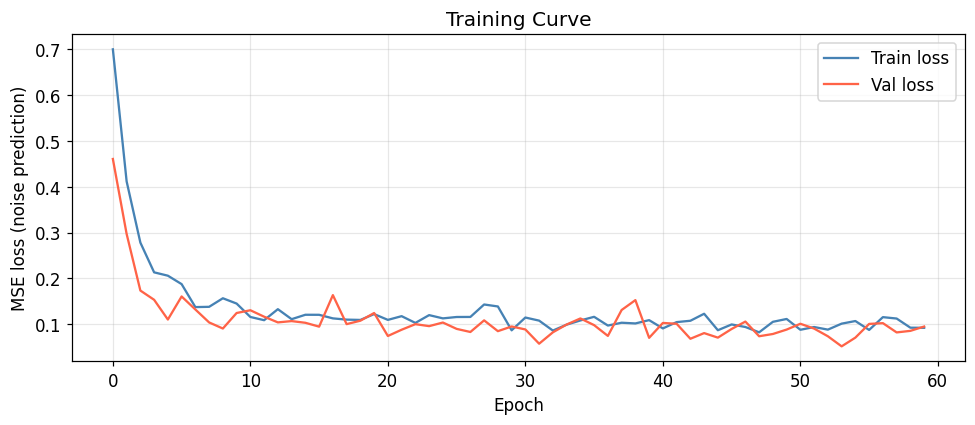

Final — train: 0.0924  val: 0.0952
Note: loss ~1.0 early is expected (predicting random noise from random noise)


In [21]:
EPOCHS = 60
LR = 3e-4

trainer = DDPMTrainer(model, schedule_mini).to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-4)

train_losses, val_losses = [], []

for epoch in tqdm(range(1, EPOCHS + 1), desc='Training'):
    # Train
    model.train()
    epoch_loss = 0.0
    for da_batch, rt_batch in train_loader:
        da_batch, rt_batch = da_batch.to(device), rt_batch.to(device)
        optimizer.zero_grad(set_to_none=True)
        loss = trainer.loss(rt_batch, da_batch)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        epoch_loss += loss.item()
    train_losses.append(epoch_loss / len(train_loader))

    # Validate
    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for da_batch, rt_batch in val_loader:
            val_loss += trainer.loss(rt_batch.to(device), da_batch.to(device)).item()
    val_losses.append(val_loss / len(val_loader))

# Plot training curve
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(train_losses, label='Train loss', color='steelblue')
ax.plot(val_losses,   label='Val loss',   color='tomato')
ax.set_xlabel('Epoch'); ax.set_ylabel('MSE loss (noise prediction)')
ax.set_title('Training Curve')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f'Final — train: {train_losses[-1]:.4f}  val: {val_losses[-1]:.4f}')
print('Note: loss ~1.0 early is expected (predicting random noise from random noise)')

## 7. Sampling — DDPM vs DDIM

We condition on the DA prices for a held-out day and draw multiple RT realizations.

- **DDPM**: full `T=200` reverse steps, stochastic (each sample is different)
- **DDIM**: only `S=20` steps, deterministic (given the same starting noise, always the same output)

Both use the exact same trained weights.

In [22]:
# Use a held-out day (after the training window)
held_out_idx = N_TRAIN + N_VAL + 5
print(f'Conditioning on: {dates[held_out_idx]}')

da_cond_np = da_norm_288[held_out_idx]           # (288,) normalized
da_cond = torch.tensor(da_cond_np, dtype=torch.float32).unsqueeze(0).unsqueeze(0).to(device)  # (1,1,288)
real_rt_norm = rt_norm[held_out_idx]             # (288,) normalized
real_rt = denormalize(real_rt_norm, sc_mean, sc_std)

N_SAMPLES = 10
model.eval()

with torch.no_grad():
    ddpm_norm = sample_ddpm(model, schedule_mini, da_cond, n_samples=N_SAMPLES)
    ddim_norm = sample_ddim(model, schedule_mini, da_cond, n_samples=N_SAMPLES, S=20)

ddpm_samples = denormalize(ddpm_norm.squeeze(1).cpu().numpy(), sc_mean, sc_std)  # (N, 288)
ddim_samples = denormalize(ddim_norm.squeeze(1).cpu().numpy(), sc_mean, sc_std)

da_raw_day = denormalize(da_cond_np, sc_mean, sc_std)  # DA in $/MWh for overlay

print(f'DDPM samples: {ddpm_samples.shape}  range [{ddpm_samples.min():.1f}, {ddpm_samples.max():.1f}]')
print(f'DDIM samples: {ddim_samples.shape}  range [{ddim_samples.min():.1f}, {ddim_samples.max():.1f}]')

Conditioning on: 2021-04-17
DDPM samples: (10, 288)  range [-117.2, 296.3]
DDIM samples: (10, 288)  range [-117.2, 296.3]


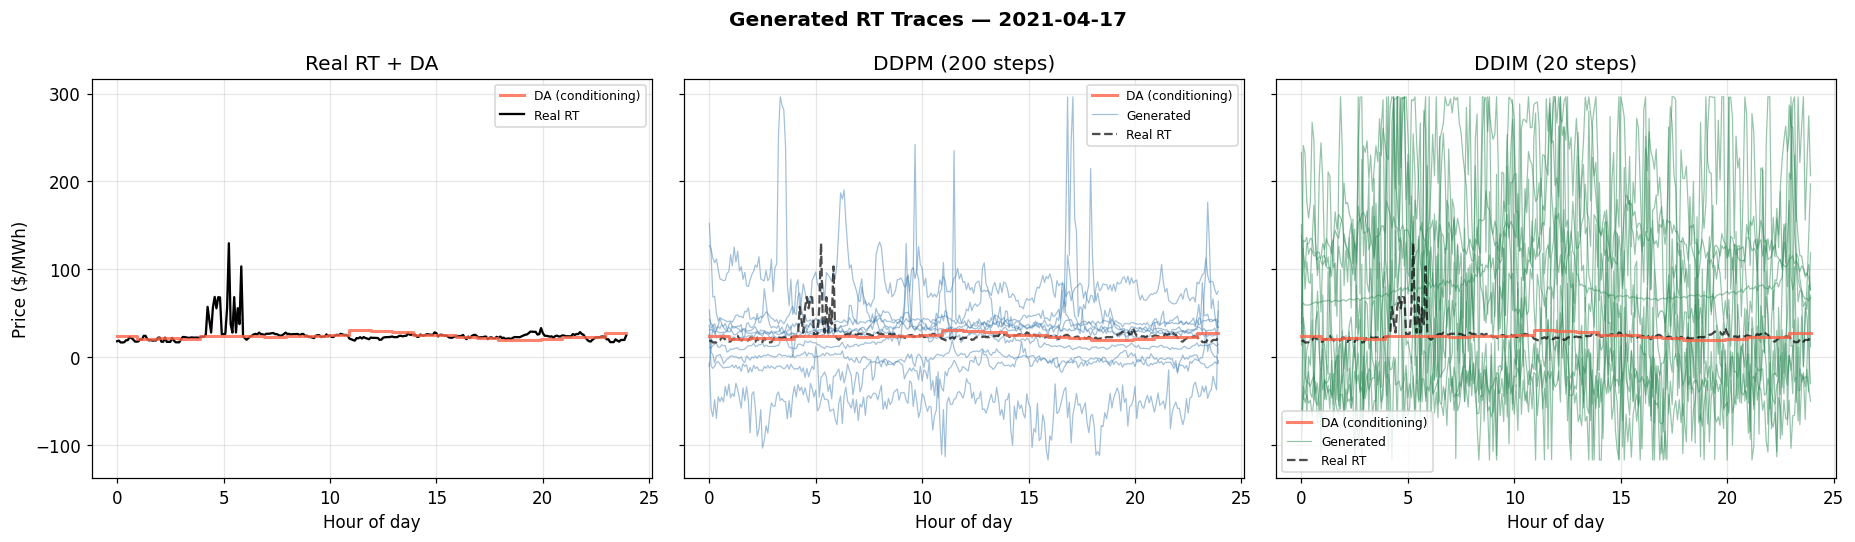

In [23]:
hours = np.arange(288) / 12

fig, axes = plt.subplots(1, 3, figsize=(17, 5), sharey=True)

for ax, (samples, title, color) in zip(axes, [
    (None,         'Real RT + DA',    None),
    (ddpm_samples, 'DDPM (200 steps)', 'steelblue'),
    (ddim_samples, 'DDIM (20 steps)',  'seagreen'),
]):
    # DA conditioning in all panels
    ax.step(hours, da_raw_day, color='tomato', lw=2, alpha=0.8, where='pre', label='DA (conditioning)', zorder=3)

    if samples is None:
        ax.plot(hours, real_rt, color='black', lw=1.5, label='Real RT', zorder=2)
    else:
        for i, s in enumerate(samples):
            ax.plot(hours, s, color=color, lw=0.8, alpha=0.5, label='Generated' if i == 0 else None)
        ax.plot(hours, real_rt, color='black', lw=1.5, ls='--', alpha=0.7, label='Real RT', zorder=2)

    ax.set_title(title); ax.set_xlabel('Hour of day')
    ax.legend(fontsize=8); ax.grid(alpha=0.3)

axes[0].set_ylabel('Price ($/MWh)')
plt.suptitle(f'Generated RT Traces — {dates[held_out_idx]}', fontweight='bold')
plt.tight_layout()
plt.show()

## 8. Sampling Speed — DDPM vs DDIM

DDIM's main practical advantage is speed. Let's measure it.

In [24]:
import time

model.eval()

def time_sampler(fn, n_runs=3):
    with torch.no_grad():
        fn()  # warmup
        t0 = time.time()
        for _ in range(n_runs):
            fn()
        return (time.time() - t0) / n_runs

t_ddpm = time_sampler(lambda: sample_ddpm(model, schedule_mini, da_cond, n_samples=1))
t_ddim = time_sampler(lambda: sample_ddim(model, schedule_mini, da_cond, n_samples=1, S=20))

print(f'DDPM (T=200 steps): {t_ddpm*1000:.1f} ms per sample')
print(f'DDIM (S=20  steps): {t_ddim*1000:.1f} ms per sample')
print(f'Speedup: {t_ddpm/t_ddim:.1f}×')

DDPM (T=200 steps): 1285.8 ms per sample
DDIM (S=20  steps): 133.4 ms per sample
Speedup: 9.6×


## 9. Evaluation — Does It Look Realistic?

Since the goal is **statistical realism** (not point-forecast accuracy), we compare:
- Price distributions
- Hourly volatility profiles (which hours are most volatile?)
- Autocorrelation (does price persistence look right?)

In [25]:
# Generate samples for all val days
model.eval()
all_ddpm, all_ddim = [], []

with torch.no_grad():
    for i in tqdm(range(N_TRAIN, N_TRAIN + N_VAL), desc='Sampling val days'):
        cond = torch.tensor(da_norm_288[i], dtype=torch.float32).unsqueeze(0).unsqueeze(0).to(device)
        ddpm_s = sample_ddpm(model, schedule_mini, cond, n_samples=3)  # 3 samples per day
        ddim_s = sample_ddim(model, schedule_mini, cond, n_samples=3, S=20)
        all_ddpm.append(ddpm_s.squeeze(1).cpu().numpy())
        all_ddim.append(ddim_s.squeeze(1).cpu().numpy())

ddpm_eval = denormalize(np.concatenate(all_ddpm, axis=0), sc_mean, sc_std)  # (N_VAL*3, 288)
ddim_eval = denormalize(np.concatenate(all_ddim, axis=0), sc_mean, sc_std)
real_eval  = rt_arr[N_TRAIN:N_TRAIN + N_VAL]                               # (N_VAL, 288)

print(f'Shapes — real: {real_eval.shape}  ddpm: {ddpm_eval.shape}  ddim: {ddim_eval.shape}')

Sampling val days:   0%|          | 0/30 [00:00<?, ?it/s]

Shapes — real: (30, 288)  ddpm: (90, 288)  ddim: (90, 288)


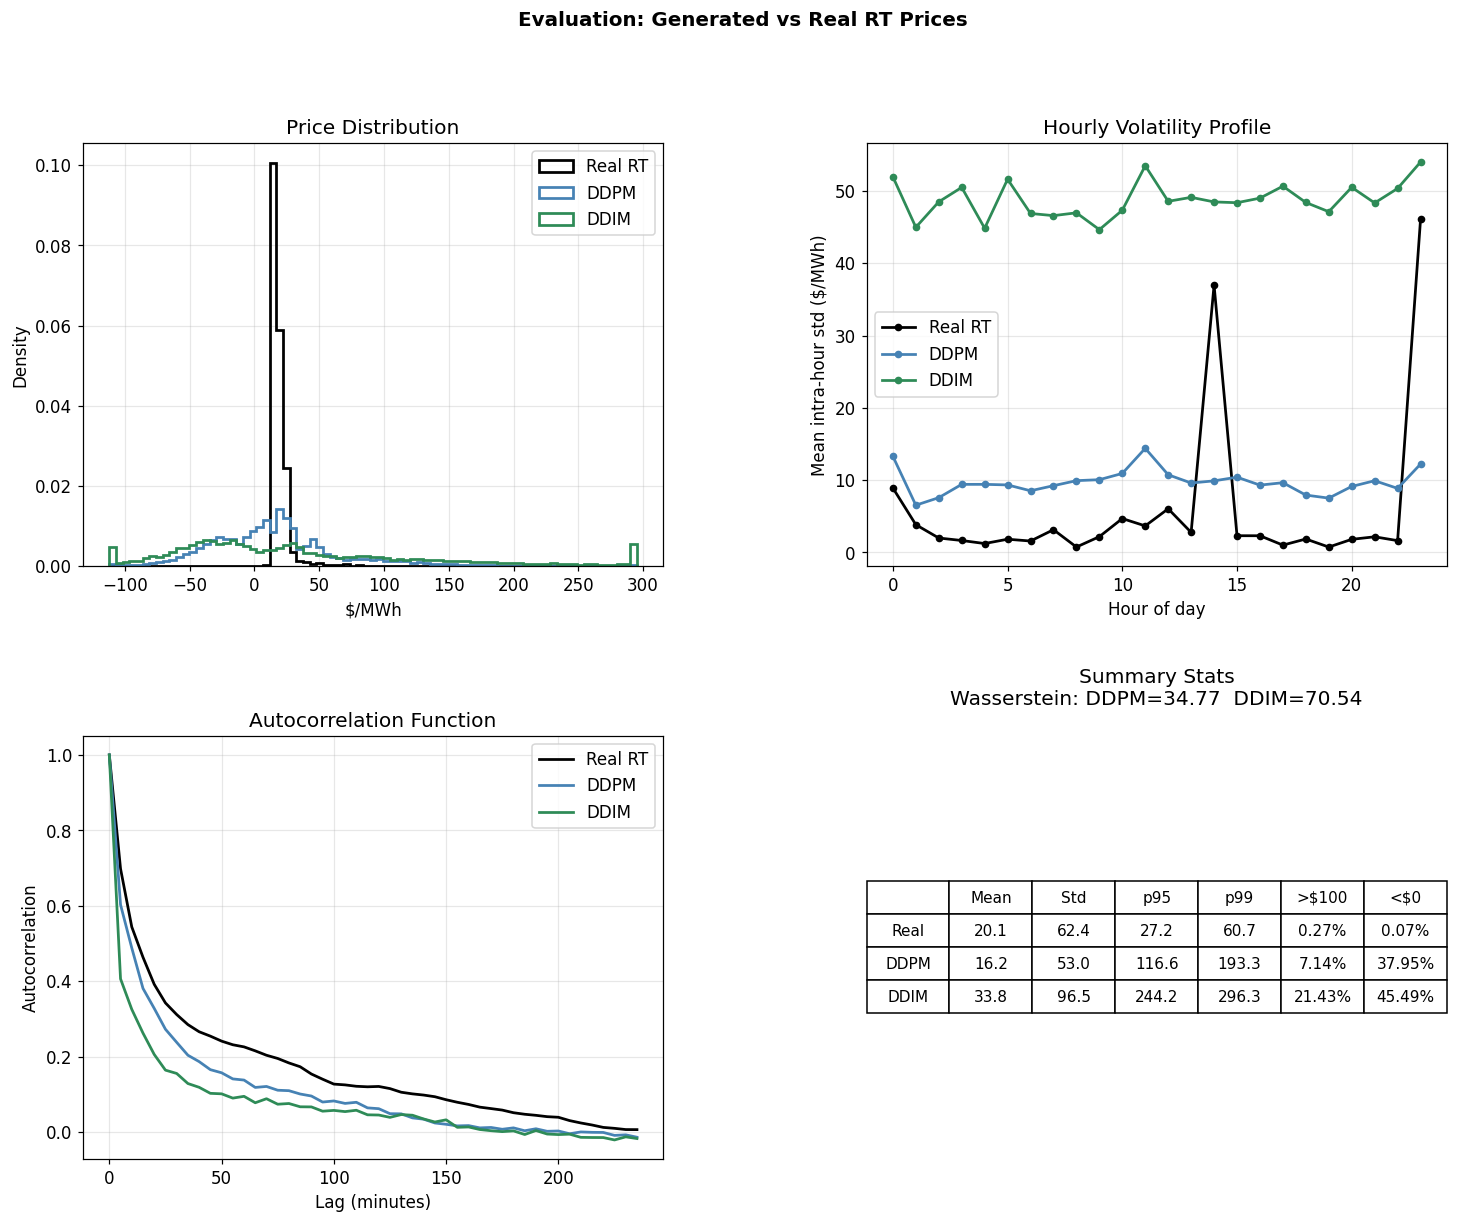

In [26]:
from scipy import stats

fig = plt.figure(figsize=(16, 12))
gs = gridspec.GridSpec(2, 2, hspace=0.4, wspace=0.35)

# ── Distribution ──────────────────────────────────────────────────────────────
ax = fig.add_subplot(gs[0, 0])
clip_hi = np.percentile(np.concatenate([real_eval, ddpm_eval, ddim_eval]), 99)
clip_lo = np.percentile(np.concatenate([real_eval, ddpm_eval, ddim_eval]), 1)
bins = np.linspace(clip_lo, clip_hi, 80)

for arr, label, color in [
    (real_eval,  'Real RT',  'black'),
    (ddpm_eval,  'DDPM',     'steelblue'),
    (ddim_eval,  'DDIM',     'seagreen'),
]:
    ax.hist(np.clip(arr.ravel(), clip_lo, clip_hi), bins=bins, density=True,
            histtype='step', label=label, color=color, lw=1.8)

ax.set_title('Price Distribution'); ax.set_xlabel('$/MWh'); ax.set_ylabel('Density')
ax.legend(); ax.grid(alpha=0.3)

# ── Hourly Volatility ─────────────────────────────────────────────────────────
ax = fig.add_subplot(gs[0, 1])

def hourly_vol(arr):
    return arr.reshape(arr.shape[0], 24, 12).std(axis=2).mean(axis=0)

for arr, label, color in [
    (real_eval, 'Real RT', 'black'),
    (ddpm_eval, 'DDPM',    'steelblue'),
    (ddim_eval, 'DDIM',    'seagreen'),
]:
    hv = hourly_vol(arr)
    ax.plot(np.arange(24), hv, color=color, lw=1.8, marker='o', ms=4, label=label)

ax.set_title('Hourly Volatility Profile'); ax.set_xlabel('Hour of day')
ax.set_ylabel('Mean intra-hour std ($/MWh)'); ax.legend(); ax.grid(alpha=0.3)

# ── Autocorrelation ───────────────────────────────────────────────────────────
ax = fig.add_subplot(gs[1, 0])

def mean_acf(arr, max_lag=48):
    acfs = []
    for row in arr:
        x = row - row.mean()
        full = np.correlate(x, x, mode='full')
        full = full[full.size // 2:]
        acfs.append(full[:max_lag] / full[0])
    return np.stack(acfs).mean(axis=0)

lags = np.arange(48) * 5  # in minutes
for arr, label, color in [
    (real_eval, 'Real RT', 'black'),
    (ddpm_eval, 'DDPM',    'steelblue'),
    (ddim_eval, 'DDIM',    'seagreen'),
]:
    ax.plot(lags, mean_acf(arr), color=color, lw=1.8, label=label)

ax.set_title('Autocorrelation Function'); ax.set_xlabel('Lag (minutes)')
ax.set_ylabel('Autocorrelation'); ax.legend(); ax.grid(alpha=0.3)

# ── Summary Stats Table ───────────────────────────────────────────────────────
ax = fig.add_subplot(gs[1, 1])
ax.axis('off')

rows = []
for arr, label in [(real_eval, 'Real'), (ddpm_eval, 'DDPM'), (ddim_eval, 'DDIM')]:
    flat = arr.ravel()
    rows.append([
        label,
        f'{flat.mean():.1f}',
        f'{flat.std():.1f}',
        f'{np.percentile(flat, 95):.1f}',
        f'{np.percentile(flat, 99):.1f}',
        f'{(flat > 100).mean():.2%}',
        f'{(flat < 0).mean():.2%}',
    ])
    
w_ddpm = stats.wasserstein_distance(real_eval.ravel(), ddpm_eval.ravel())
w_ddim = stats.wasserstein_distance(real_eval.ravel(), ddim_eval.ravel())

table = ax.table(
    cellText=rows,
    colLabels=['', 'Mean', 'Std', 'p95', 'p99', '>$100', '<$0'],
    loc='center', cellLoc='center'
)
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1, 1.8)
ax.set_title(f'Summary Stats\nWasserstein: DDPM={w_ddpm:.2f}  DDIM={w_ddim:.2f}', pad=20)

plt.suptitle('Evaluation: Generated vs Real RT Prices', fontweight='bold', fontsize=13)
plt.show()

## 10. Battery Arbitrage Evaluation

The primary downstream metric: run the battery LP on real vs generated prices and compare the **revenue** the optimal battery schedule would earn.

**Setup**: 1 MW / 4 MWh battery, 95% round-trip efficiency, `require_equivalent_soe=True` so the battery ends each day at its starting SOC — making revenues comparable across days.

Two things we're measuring:
- **Revenue distribution match** — does the model generate prices with similar economic value embedded in their volatility structure?
- **Revenue delta (bias)** — does the model systematically over- or under-estimate the value of intra-day arbitrage?

Set parameter Username
Academic license - for non-commercial use only - expires 2026-12-16
Real RT revenue for example day: $15.93


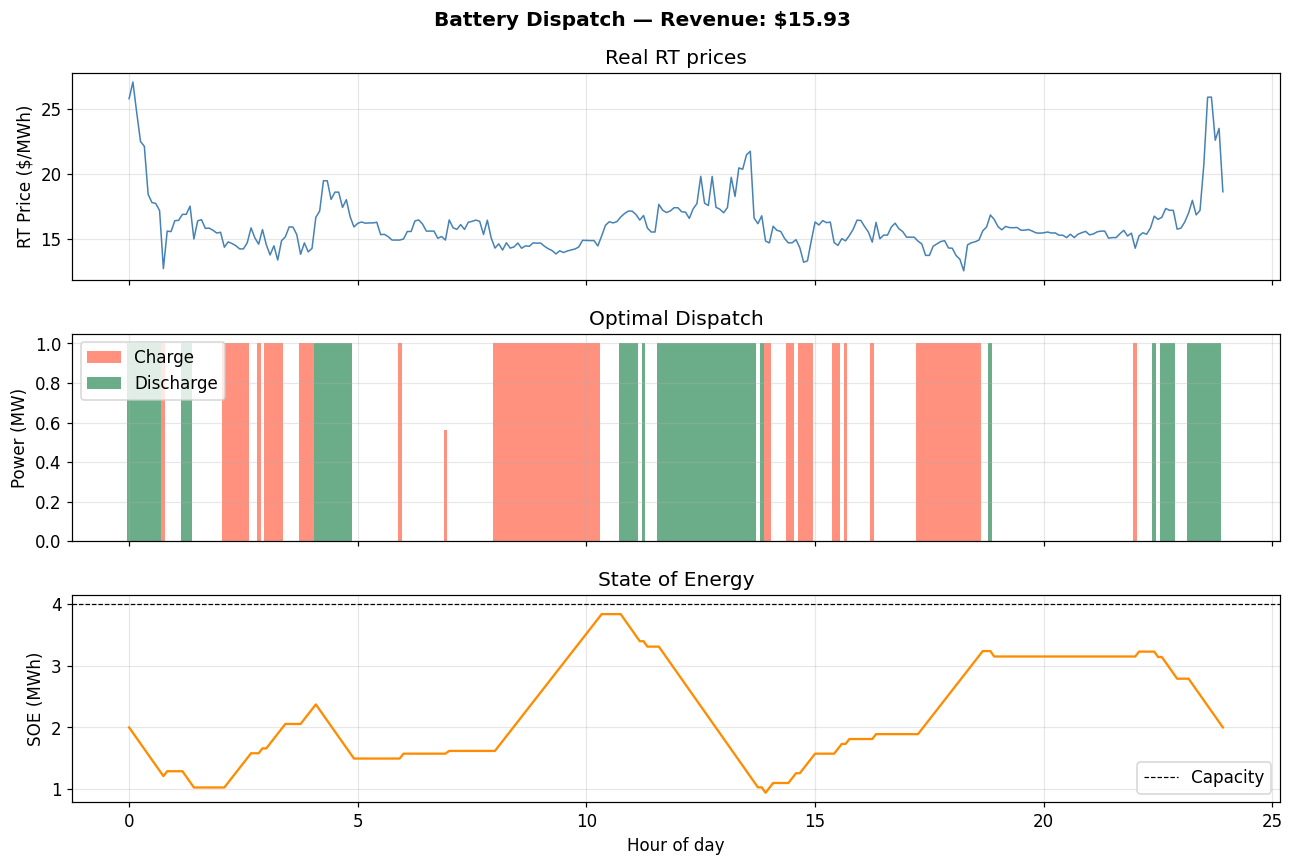

In [27]:
from battery import deterministic_arbitrage_opt, prices_to_df

# Show what the optimal dispatch looks like for one real day
example_prices = real_eval[0]   # (288,) $/MWh
dispatch_df, revenue = deterministic_arbitrage_opt(prices_to_df(example_prices))
print(f'Real RT revenue for example day: ${revenue:.2f}')

hours = np.arange(288) / 12
fig, axes = plt.subplots(3, 1, figsize=(12, 8), sharex=True)

axes[0].plot(hours, example_prices, color='steelblue', lw=1)
axes[0].set_ylabel('RT Price ($/MWh)'); axes[0].set_title('Real RT prices'); axes[0].grid(alpha=0.3)

axes[1].bar(hours, dispatch_df['charge_mw'].values,    width=1/12, color='tomato',   alpha=0.7, label='Charge')
axes[1].bar(hours, dispatch_df['discharge_mw'].values, width=1/12, color='seagreen', alpha=0.7, label='Discharge')
axes[1].set_ylabel('Power (MW)'); axes[1].set_title('Optimal Dispatch'); axes[1].legend(); axes[1].grid(alpha=0.3)

axes[2].plot(hours, dispatch_df['state_of_energy_mwh'].values, color='darkorange', lw=1.5)
axes[2].axhline(4.0, color='black', ls='--', lw=0.8, label='Capacity')
axes[2].set_ylabel('SOE (MWh)'); axes[2].set_xlabel('Hour of day')
axes[2].set_title('State of Energy'); axes[2].legend(); axes[2].grid(alpha=0.3)

plt.suptitle(f'Battery Dispatch — Revenue: ${revenue:.2f}', fontweight='bold')
plt.tight_layout()
plt.show()

In [28]:
from battery import batch_revenue

# Run LP on all val days (real) and all generated samples
# Use 1 DDPM sample and 1 DDIM sample per real day for speed in the walkthrough
ddpm_1per = ddpm_eval[::3]   # every 3rd sample = 1 per day (we generated 3/day)
ddim_1per = ddim_eval[::3]

real_rev = batch_revenue(real_eval,  desc='real RT  ')
ddpm_rev = batch_revenue(ddpm_1per,  desc='DDPM     ')
ddim_rev = batch_revenue(ddim_1per,  desc='DDIM     ')

print(f'\n{"─"*55}')
print(f'  Revenue ($/day)       Mean    Std    Median')
print(f'{"─"*55}')
for label, arr in [("Real RT", real_rev), ("DDPM", ddpm_rev), ("DDIM", ddim_rev)]:
    print(f'  {label:18s}  {arr.mean():>7.2f}  {arr.std():>6.2f}  {np.median(arr):>7.2f}')
print(f'{"─"*55}')
delta_ddpm = ddpm_rev - real_rev
delta_ddim = ddim_rev - real_rev
print(f'  {"DDPM delta":18s}  {delta_ddpm.mean():>+7.2f}  {delta_ddpm.std():>6.2f}  (RMSE {np.sqrt((delta_ddpm**2).mean()):.2f})')
print(f'  {"DDIM delta":18s}  {delta_ddim.mean():>+7.2f}  {delta_ddim.std():>6.2f}  (RMSE {np.sqrt((delta_ddim**2).mean()):.2f})')


───────────────────────────────────────────────────────
  Revenue ($/day)       Mean    Std    Median
───────────────────────────────────────────────────────
  Real RT               85.02  114.24    46.47
  DDPM                 209.12  214.36   112.45
  DDIM                1181.41  636.64  1207.40
───────────────────────────────────────────────────────
  DDPM delta          +124.10  260.18  (RMSE 288.26)
  DDIM delta          +1096.39  664.79  (RMSE 1282.19)


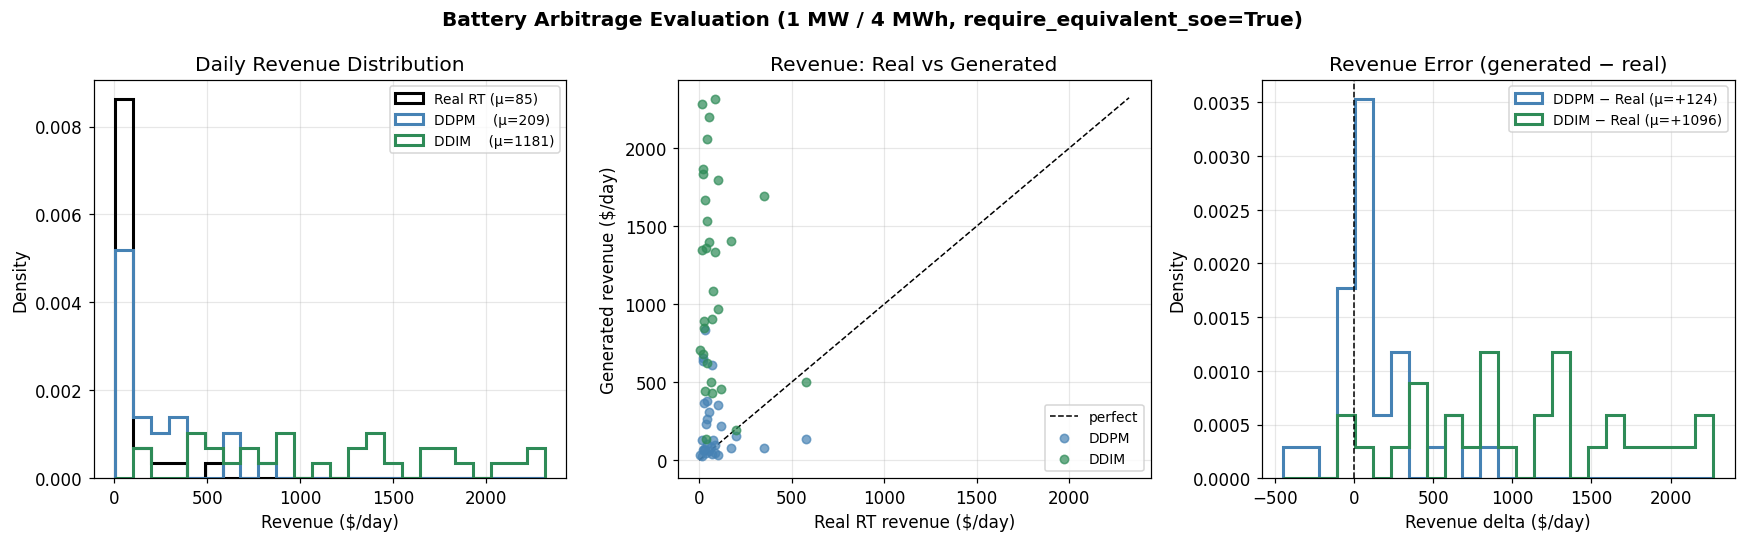


Interpretation:
  A positive delta mean means the model thinks there is MORE arbitrage opportunity
  than actually exists — it over-generates volatility.
  The RMSE captures day-to-day accuracy: how well the generated prices predict
  the economic value of real prices on a given day.


In [29]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Revenue distributions
ax = axes[0]
all_rev = np.concatenate([real_rev, ddpm_rev, ddim_rev])
bins = np.linspace(all_rev.min(), all_rev.max(), 25)
for arr, label, color in [
    (real_rev, f'Real RT (μ={real_rev.mean():.0f})',  'black'),
    (ddpm_rev, f'DDPM    (μ={ddpm_rev.mean():.0f})',  'steelblue'),
    (ddim_rev, f'DDIM    (μ={ddim_rev.mean():.0f})',  'seagreen'),
]:
    ax.hist(arr, bins=bins, histtype='step', density=True, label=label, color=color, lw=2)
ax.set_xlabel('Revenue ($/day)'); ax.set_ylabel('Density')
ax.set_title('Daily Revenue Distribution'); ax.legend(fontsize=9); ax.grid(alpha=0.3)

# Scatter: real vs generated revenue per day
ax = axes[1]
lims = [min(real_rev.min(), ddpm_rev.min(), ddim_rev.min()) - 5,
        max(real_rev.max(), ddpm_rev.max(), ddim_rev.max()) + 5]
ax.plot(lims, lims, 'k--', lw=1, label='perfect')
ax.scatter(real_rev, ddpm_rev, s=30, alpha=0.7, color='steelblue', label='DDPM', zorder=3)
ax.scatter(real_rev, ddim_rev, s=30, alpha=0.7, color='seagreen',  label='DDIM', zorder=3)
ax.set_xlabel('Real RT revenue ($/day)'); ax.set_ylabel('Generated revenue ($/day)')
ax.set_title('Revenue: Real vs Generated'); ax.legend(fontsize=9); ax.grid(alpha=0.3)

# Delta distribution (bias)
ax = axes[2]
all_delta = np.concatenate([delta_ddpm, delta_ddim])
bins_d = np.linspace(all_delta.min(), all_delta.max(), 25)
for arr, label, color in [
    (delta_ddpm, f'DDPM − Real (μ={delta_ddpm.mean():+.0f})', 'steelblue'),
    (delta_ddim, f'DDIM − Real (μ={delta_ddim.mean():+.0f})', 'seagreen'),
]:
    ax.hist(arr, bins=bins_d, histtype='step', density=True, label=label, color=color, lw=2)
ax.axvline(0, color='black', lw=1, ls='--')
ax.set_xlabel('Revenue delta ($/day)'); ax.set_ylabel('Density')
ax.set_title('Revenue Error (generated − real)'); ax.legend(fontsize=9); ax.grid(alpha=0.3)

plt.suptitle('Battery Arbitrage Evaluation (1 MW / 4 MWh, require_equivalent_soe=True)',
             fontweight='bold')
plt.tight_layout()
plt.show()

print('\nInterpretation:')
print(f'  A positive delta mean means the model thinks there is MORE arbitrage opportunity')
print(f'  than actually exists — it over-generates volatility.')
print(f'  The RMSE captures day-to-day accuracy: how well the generated prices predict')
print(f'  the economic value of real prices on a given day.')

## 11. What's Missing vs the Full Model

This walkthrough uses a deliberately tiny setup. The full training run (`train.py`) uses:

| Setting | Walkthrough | Full |
|---|---|---|
| Training days | 150 | 1151 |
| `base_channels` | 16 | 64 |
| `num_res_blocks` | 1 | 2 |
| `T` (diffusion steps) | 200 | 1000 |
| Epochs | 60 | 300 |
| Parameters | ~100K | ~6.5M |

The quality here will be limited — the distribution and ACF won't match well yet. That's expected.
The full model trained on 1151 days for 300 epochs should produce significantly more realistic samples.

**To train the full model:**
```bash
python train.py --config configs/default.yaml
```

**To generate samples from a trained checkpoint:**
```bash
python sample.py --config configs/default.yaml --checkpoint runs/best.pt --n_samples 20
python sample.py --config configs/default.yaml --checkpoint runs/best.pt --n_samples 20 --ddim
```

**To run the full evaluation (volatility stats + all plots):**
```bash
python evaluate.py --config configs/default.yaml \
    --ddpm_samples runs/samples_ddpm.npz \
    --ddim_samples runs/samples_ddim.npz \
    --real_npz data/test.npz
```